# Gradient Boosting for Regression (Mathematical Formulation)

## Input
- Training set: $$ \{(x_i, y_i)\}_{i=1}^{N} $$
- A differentiable loss function: $$ L(y, F(x)) $$
- Number of iterations: $$ M $$

---

## Algorithm

### 1. Initialize model

$$
f_0(x) = \arg\min_{\gamma} \sum_{i=1}^{N} L(y_i, \gamma)
$$

---

### 2. For $$ m = 1 $$ to $$ M $$:

#### (a) Compute pseudo-residuals

For $$ i = 1, 2, \dots, N $$:

$$
r_{im} = - \left[ \frac{\partial L(y_i, f(x_i))}{\partial f(x_i)} \right]_{f = f_{m-1}}
$$

---

#### (b) Fit regression tree

Fit a regression tree to the targets $$ r_{im} $$, producing terminal regions:

$$
R_{jm}, \quad j = 1, 2, \dots, J_m
$$

---

#### (c) Compute optimal value for each region

For $$ j = 1, 2, \dots, J_m $$:

$$
\gamma_{jm} = \arg\min_{\gamma} \sum_{x_i \in R_{jm}} L(y_i, f_{m-1}(x_i) + \gamma)
$$

---

#### (d) Update model

$$
f_m(x) = f_{m-1}(x) + \sum_{j=1}^{J_m} \gamma_{jm} \cdot I(x \in R_{jm})
$$

---

### 3. Output final model

$$
\hat{f}(x) = f_M(x)
$$

---------------

-----------

# Additive Modelling 

# What Does Machine Learning Actually Do?

At its core, **Machine Learning (ML)** is about learning a function from data.



## Core Idea

A machine learning model is essentially a **mathematical function**:

$$
f(x) \approx y
$$

Where:
- $$ x $$ = input (features)
- $$ y $$ = output (target)
- $$ f $$ = learned function (model)



## What Are We Really Doing?

We are trying to find a function $$ f $$ such that:

$$
f(x_i) \approx y_i \quad \forall i
$$

Given a dataset:

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$



## Learning = Function Approximation

Machine Learning is basically:

> **Finding the best function that maps inputs to outputs using data**

We don’t manually define the function —  
we let the algorithm **learn it from data**.



## How Do We Find This Function?

We define a **loss function** that measures error:

$$
L(y, f(x))
$$

Then we optimize:

$$
\min_f \sum_{i=1}^{N} L(y_i, f(x_i))
$$



## Different Models = Different Function Families

Different ML algorithms assume different types of functions:

- **Linear Regression** → linear function  
  $$
  f(x) = wx + b
  $$

- **Decision Trees** → piecewise constant functions  

- **Neural Networks** → highly complex non-linear functions  

- **Gradient Boosting** → sum of weak functions  
  $$
  f(x) = \sum_{m=1}^{M} f_m(x)
  $$



## Intuition

Think of ML as:

- You have data points
- You are trying to **draw the best curve/function**
- That curve should **generalize to unseen data**


> Machine Learning is the process of learning a function from data that maps inputs to outputs with minimal error.

# Additive Modeling in Machine Learning

## What is Additive Modeling?

In many real-world problems, the true relationship between input and output is **complex**.

Instead of trying to learn one complicated function directly, we:

> **Break the function into a sum of smaller, simpler functions**

## Core Idea

We want to learn a function:

$$
f(x)
$$

But instead of learning it all at once, we write it as:

$$
f(x) = f_1(x) + f_2(x) + f_3(x) + \dots + f_M(x)
$$

Each $$ f_m(x) $$ is a **simple function (weak learner)**.

## Why Do This?

Learning a highly complex function directly is:
- Hard to optimize
- Prone to overfitting or instability

> Additive modeling makes it easier by:
- Learning step-by-step
- Improving the model gradually

## Connection to Runge’s Phenomenon

When we try to fit a single high-degree polynomial to complex data, we may get large oscillations.

> This is known as **Runge’s Phenomenon**.

Instead of using one complex function, additive modeling:
- Uses multiple small functions
- Builds a stable approximation

## Additive Modeling in Boosting

Boosting algorithms (like Gradient Boosting) use additive modeling.

We build the model as:

$$
f(x) = \sum_{m=1}^{M} f_m(x)
$$

Where:
- Each $$ f_m(x) $$ is usually a **small decision tree**
- Each new function tries to **correct previous errors**

## Step-by-Step Intuition

1. Start with a simple model  
2. Add a new function to fix errors  
3. Repeat multiple times  
4. Final model = sum of all small models  

## Example (Gradient Boosting)

Instead of one big model:

$$
f(x)
$$

We build:

$$
f(x) = f_1(x) + f_2(x) + f_3(x) + \dots
$$

Each step:
- Focuses on mistakes of previous model
- Improves the overall prediction

## One-Line Summary

> Additive modeling builds a complex function by combining many simple functions step-by-step.

-----
# Understanding Algorithm

# STEP - 1

# Input for Gradient Boosting 

## Training Set

The training data is:

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

### In our dataset:

| R\&D Spend | Administration | Marketing Spend | Profit |
|-----------|---------------|----------------|--------|
| 165       | 137           | 472            | 192    |
| 101       | 92            | 250            | 144    |
| 29        | 127           | 201            | 91     |

- $$ x_i $$ = input features  

$$
x_i = [\text{R\&D Spend}, \text{Administration}, \text{Marketing Spend}]
$$

- $$ y_i $$ = target value  

$$
y_i = \text{Profit}
$$

## Loss Function

We define a loss function:

$$
L(y, F(x))
$$

It measures how far the prediction $$ F(x) $$ is from the true value $$ y $$.

### For regression (used here):

$$
L(y, F(x)) = (y - F(x))^2
$$

This is called **Mean Squared Error (MSE)**.

## Number of Iterations

$$
M
$$

- $$ M $$ = number of boosting steps  
- At each step, we add one new model (tree)

### Example:

- $$ M = 3 $$ → 3 trees  
- $$ M = 100 $$ → 100 trees  

## Intuition

- Dataset gives examples of input → output  
- Loss function tells how wrong we are  
- Iterations tell how many times we improve  

## One-Line Summary

> Input = Data + Loss Function + Number of Steps to Improve the Model

In [1]:
import pandas as pd

data = {
    "R&D Spend": [165.0, 101.0, 29.0],
    "Administration": [137.0, 92.0, 127.0],
    "Marketing Spend": [472.0, 250.0, 201.0],
    "Profit": [192.0, 144.0, 91.0]
}

df = pd.DataFrame(data)

print(df)

   R&D Spend  Administration  Marketing Spend  Profit
0      165.0           137.0            472.0   192.0
1      101.0            92.0            250.0   144.0
2       29.0           127.0            201.0    91.0


# Loss Function in Gradient Boosting

A differentiable loss function is required:

$$
L(y, F(x)) \equiv L(y, \hat{y})
$$

where:
- $$ y $$ = true value  
- $$ \hat{y} = F(x) $$ = predicted value  

## Choice of Loss Function

For regression, we use the **least squares loss**:

$$
L(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2
$$

## Why Multiply by 1/2?

The factor $$ \frac{1}{2} $$ is introduced for **mathematical convenience**.

When taking derivatives:

$$
\frac{d}{d\hat{y}} \left( \frac{1}{2}(y - \hat{y})^2 \right) = -(y - \hat{y})
$$

Without $$ \frac{1}{2} $$:

$$
\frac{d}{d\hat{y}} (y - \hat{y})^2 = -2(y - \hat{y})
$$

Thus, the factor removes the constant $$ 2 $$, simplifying gradient calculations.

## Does 1/2 Affect the Model?

No.

- It does not change the location of the minimum  
- It only scales the loss, not the optimization outcome  

## 

- We use a differentiable loss function  
- For regression, we use least squares loss  
- The factor $$ \frac{1}{2} $$ simplifies derivatives  
- It has no effect on the final model  



# Additive Model and Initialization in Gradient Boosting

## Additive Modeling

We construct the target function as a sum of smaller functions:

$$
f(x) = f_0(x) + f_1(x) + f_2(x) + \dots + f_n(x)
$$

Each component function incrementally improves the overall model.

## Initialization Step

The first function is defined as:

$$
f_0(x) = \arg\min_{\gamma} \sum_{i=1}^{N} L(y_i, \gamma)
$$

## Meaning of $$ \gamma $$

$$
\gamma
$$

is a constant value that minimizes the loss function. It represents the best constant prediction for all data points.

## Solving for $$ f_0(x) $$

Using least squares loss:

$$
L(y_i, \gamma) = \frac{1}{2}(y_i - \gamma)^2
$$

We minimize:

$$
\sum_{i=1}^{N} \frac{1}{2}(y_i - \gamma)^2
$$

## Optimization

To find the optimal $$ \gamma $$:

1. Differentiate with respect to $$ \gamma $$
2. Set derivative equal to zero

$$
\frac{d}{d\gamma} \sum_{i=1}^{N} \frac{1}{2}(y_i - \gamma)^2 = 0
$$

This is a standard optimization step.


## Derivation of Optimal $$ \gamma $$

We start with the objective:

$$
\frac{d}{d\gamma} \left( \frac{1}{2} \sum_{i=1}^{N} (y_i - \gamma)^2 \right)
$$

### Step 1: Move derivative inside summation

$$
= \frac{1}{2} \sum_{i=1}^{N} \frac{d}{d\gamma} (y_i - \gamma)^2
$$

### Step 2: Apply chain rule

$$
= \frac{1}{2} \sum_{i=1}^{N} 2 (y_i - \gamma) \cdot \frac{d}{d\gamma}(y_i - \gamma)
$$

### Step 3: Differentiate inner term

$$
\frac{d}{d\gamma}(y_i - \gamma) = -1
$$

So,

$$
= \frac{1}{2} \sum_{i=1}^{N} 2 (y_i - \gamma)(-1)
$$

### Step 4: Simplify

$$
= - \sum_{i=1}^{N} (y_i - \gamma)
$$

### Step 5: Set derivative to zero

$$
- \sum_{i=1}^{N} (y_i - \gamma) = 0
$$

$$
\sum_{i=1}^{N} (y_i - \gamma) = 0
$$

### Step 6: Expand

$$
\sum_{i=1}^{N} y_i - \sum_{i=1}^{N} \gamma = 0
$$

$$
\sum_{i=1}^{N} y_i - N\gamma = 0
$$

### Step 7: Solve for $$ \gamma $$

$$
\gamma = \frac{1}{N} \sum_{i=1}^{N} y_i
$$

## Applying Initialization on Our Dataset

We solve:

$$
\sum_{i=1}^{3} (y_i - \gamma) = 0
$$

Substituting values from our dataset:

$$
(192 - \gamma) + (144 - \gamma) + (91 - \gamma) = 0
$$

### Rearranging

$$
192 + 144 + 91 - 3\gamma = 0
$$

$$
192 + 144 + 91 = 3\gamma
$$

### Solving

$$
\gamma = \frac{192 + 144 + 91}{3}
$$

$$
\gamma = \frac{427}{3} = 142.33
$$

## Conclusion

$$
f_0(x) = 142.33
$$

- The first model predicts a constant value for all inputs  
- This value is the **mean of the target (Profit) column**  
- This matches the theoretical result:

$$
f_0(x) = \text{mean}(y)
$$

# STEP - 2

We now move to the iterative stage of Gradient Boosting.

The model is built as an additive function:

$$
F(x) = f_0(x) + f_1(x) + f_2(x) + \dots + f_M(x)
$$

- $$ f_0(x) $$ is a constant model (mean of target)  
- $$ f_m(x) $$ for $$ m \geq 1 $$ are decision trees  
- These trees are added sequentially to improve the model  

For this process, we set:

$$
M = 50
$$

## Step 2(a): Compute Pseudo-Residuals

For each iteration $$ m $$ and each data point $$ i $$, we compute:

$$
r_{im} = - \left[ \frac{\partial L(y_i, f(x_i))}{\partial f(x_i)} \right]_{f = f_{m-1}}
$$

Where:
- $$ i $$ = row index  
- $$ m $$ = iteration (decision tree number)  

## First Iteration (m = 1)

We use the initial model:

$$
f_0(x) = \text{mean}(y)
$$

Now compute pseudo-residuals:

$$
r_{i1} = - \left[ \frac{\partial L(y_i, f(x_i))}{\partial f(x_i)} \right]_{f = f_0}
$$

Since our dataset has 3 rows, we compute:

$$
r_{11}, \quad r_{21}, \quad r_{31}
$$

These values represent the **pseudo-residuals for the first decision tree**.

## Interpretation

- Pseudo-residuals indicate how much the model is wrong  
- They act as the new target values for the next model  
- Each new tree is trained to predict these residuals  

In [2]:
df['f0(x)'] = df['Profit'].mean()

In [3]:
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(x)
0,165.0,137.0,472.0,192.0,142.333333
1,101.0,92.0,250.0,144.0,142.333333
2,29.0,127.0,201.0,91.0,142.333333


## Computing Pseudo-Residuals (First Iteration)

We start with the definition:

$$
r_{i1} = - \left[ \frac{\partial L(y_i, \hat{y}_i)}{\partial \hat{y}_i} \right]_{f = f_0}
$$

## Loss Function

We are using least squares loss:

$$
L = \frac{1}{2} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

However, for computing pseudo-residuals, we focus on **each data point individually**, so we consider:

$$
L_i = \frac{1}{2} (y_i - \hat{y}_i)^2
$$

## Differentiation

Taking derivative with respect to $$ \hat{y}_i $$:

$$
\frac{\partial}{\partial \hat{y}_i} \left( \frac{1}{2} (y_i - \hat{y}_i)^2 \right)
$$

Applying chain rule:

$$
= (y_i - \hat{y}_i)(-1)
$$

$$
= - (y_i - \hat{y}_i)
$$

## Substitute in Residual Formula

$$
r_{i1} = - [ - (y_i - \hat{y}_i) ]
$$

$$
r_{i1} = (y_i - \hat{y}_i)
$$

## Using Initial Model

Since:

$$
\hat{y}_i = f_0(x)
$$

We get:

$$
r_{i1} = y_i - f_0(x)
$$

## Conclusion

- Pseudo-residuals = actual − predicted  
- For MSE loss, residuals are simple differences  
- These become the target for the first decision tree  

### For each data point:

$$
r_{11} = y_1 - f_0(x_1) = 192 - 142.33 = 49.67
$$

$$
r_{21} = y_2 - f_0(x_2) = 144 - 142.33 = 1.67
$$

$$
r_{31} = y_3 - f_0(x_3) = 91 - 142.33 = -51.33
$$

## Result

$$
r_{11} = 49.67, \quad r_{21} = 1.67, \quad r_{31} = -51.33
$$


In [4]:
df['r_i1'] = df['Profit'] - df['f0(x)']
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(x),r_i1
0,165.0,137.0,472.0,192.0,142.333333,49.666667
1,101.0,92.0,250.0,144.0,142.333333,1.666667
2,29.0,127.0,201.0,91.0,142.333333,-51.333333


> ##### b) Fit a regression tree to the target r_im giving terminal regions  , R_jm , j=1,2,3.....Jm.

In [5]:
from sklearn.tree import DecisionTreeRegressor
dt1 = DecisionTreeRegressor(max_depth=1) 
# region for max_depth=1 that our data is to small for now 

In [6]:
X = df[['R&D Spend', 'Administration', 'Marketing Spend']]
y = df['r_i1']

In [7]:
dt1.fit(X,y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

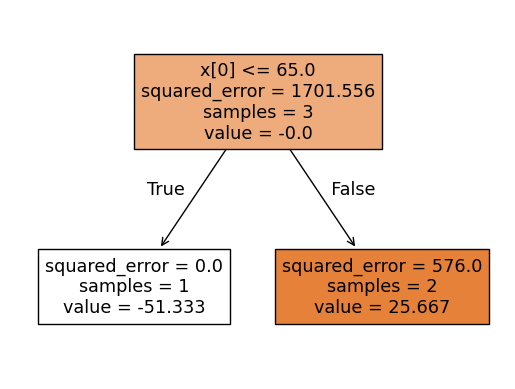

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plot_tree(dt1, filled=True)
plt.show()

## Terminal Regions in Decision Trees

Assume dataset:

$$
X \mid y
$$

Train a decision tree with:

$$
\text{max\_depth} = 1
$$

This creates a split and divides the feature space into two regions:

$$
R_{1m}, \; R_{2m}
$$

These are called **terminal regions (leaf nodes)**.

---

## Value in Each Node

For a regression tree:

$$
\text{value} = \frac{1}{|R_j|} \sum_{x_i \in R_j} y_i
$$

Example values:

$$
-51.33, \quad 25.667
$$

---

## Gradient Boosting Setting

Residuals (pseudo-residuals):

$$
r_{im} = -\left[\frac{\partial L(y_i, f(x_i))}{\partial f(x_i)}\right]
$$

For squared error loss:

$$
r_{im} = y_i - f_{m-1}(x_i)
$$

Leaf value becomes:

$$
\text{value} = \frac{1}{|R_{jm}|} \sum_{x_i \in R_{jm}} r_{im}
$$

---

## Optimal Value per Region

For each terminal region:

$$
\gamma_{jm} = \arg\min_{\gamma} \sum_{x_i \in R_{jm}} L\left(y_i, f_{m-1}(x_i) + \gamma \right)
$$

---

## For Squared Error Loss

$$
L = \frac{1}{2}(y_i - \hat{y}_i)^2
$$

Then:

$$
\gamma_{jm} = \frac{1}{|R_{jm}|} \sum_{x_i \in R_{jm}} \left(y_i - f_{m-1}(x_i)\right)
$$

---

## Model Update

$$
f_m(x) = f_{m-1}(x) + \eta \cdot \gamma_{jm}
$$

--------------

-----------

## Derivation of $\gamma_{11}$
> we didn't use summation here because there are only 1  point for this leaf

$$
\gamma_{11} = \arg\min_{\gamma} \; \frac{1}{2} \left( y_i - (f_0(x_i) + \gamma) \right)^2
$$

Take derivative w.r.t. $\gamma$:

$$
\frac{\partial L}{\partial \gamma}
= \frac{1}{2} \cdot 2 \left( y_i - (f_0(x_i) + \gamma) \right) \cdot \frac{\partial}{\partial \gamma} \left( y_i - f_0(x_i) - \gamma \right)
$$

$$
= \left( y_i - (f_0(x_i) + \gamma) \right)(-1)
$$

Set derivative to zero:

$$
- \left( y_i - f_0(x_i) - \gamma \right) = 0
$$

$$
\Rightarrow y_i - f_0(x_i) - \gamma = 0
$$

$$
\Rightarrow \gamma_{11} = y_i - f_0(x_i)
$$

--------
$$
\Rightarrow \gamma_{11} = y_i - f_0(x_i) = 91-142 = -51
$$

------

## Derivation of $$ \gamma_{21} $$

$$
\gamma_{21} = \arg\min_{\gamma} \sum_{x_i \in R_{21}} L\left(y_i, f_0(x_i) + \gamma \right)
$$

For squared error loss:

$$
= \arg\min_{\gamma} \sum_{i=1}^{2} \frac{1}{2} \left( y_i - (f_0(x_i) + \gamma) \right)^2
$$

## Differentiation

$$
\frac{\partial}{\partial \gamma}
\sum_{i=1}^{2} \frac{1}{2} \left( y_i - (f_0(x_i) + \gamma) \right)^2 = 0
$$

$$
\sum_{i=1}^{2} - \left( y_i - f_0(x_i) - \gamma \right) = 0
$$

$$
\sum_{i=1}^{2} \left( y_i - f_0(x_i) - \gamma \right) = 0
$$

## Simplification

$$
\sum_{i=1}^{2} (y_i - f_0(x_i)) - 2\gamma = 0
$$

$$
2\gamma = \sum_{i=1}^{2} (y_i - f_0(x_i))
$$

## Final Result

$$
\gamma_{21} = \frac{1}{2} \sum_{i=1}^{2} (y_i - f_0(x_i))
$$

## Interpretation

$$
\gamma_{21} = \text{mean of residuals in region } R_{21}
$$

## Numerical Calculation of $$ \gamma_{21} $$

From derivation:

$$
\sum_{i=1}^{2} (y_i - f_0(x_i) - \gamma) = 0
$$

Substitute values:

$$
(192 - 142 - \gamma) + (144 - 142 - \gamma) = 0
$$

$$
(50 - \gamma) + (2 - \gamma) = 0
$$

## Simplification

$$
50 + 2 - 2\gamma = 0
$$

$$
52 - 2\gamma = 0
$$

$$
2\gamma = 52
$$

$$
\gamma = \frac{52}{2}
$$

## Final Value

$$
\gamma_{21} = 26
$$

## Interpretation

- $$ \gamma_{21} $$ is the **average residual in region $$ R_{21} $$**
- Residuals used: $$ 50 $$ and $$ 2 $$  
- Mean = $$ (50 + 2)/2 = 26 $$

----
## Why is the Output Equal to the Leaf Value?

In Gradient Boosting with **least squares loss**, the value assigned to each leaf is:

$$
\gamma = \arg\min_{\gamma} \sum (y_i - (f(x_i) + \gamma))^2
$$

Solving this gives:

$$
\gamma = \text{mean of residuals in that leaf}
$$

## Key Insight

- The tree is trained on **residuals**
- Each leaf groups similar residuals
- The optimal constant prediction for that region is the **mean**

Thus:

> Leaf output = optimal $$ \gamma $$ = mean residual

## Important Note

This happens **only because we are using least squares loss**.

For other loss functions:
- The optimal $$ \gamma $$ is **not necessarily the mean**
- It depends on minimizing that specific loss

### Examples

- Absolute Loss → median  
- Logistic Loss → log-odds based update  

## 

> For MSE, leaf values = mean of residuals  
> For other loss functions, leaf values are computed differently

---------
--------

## Step 2(d): Update the Model

After computing the leaf values $$ \gamma_{jm} $$, we update the model:

$$
f_m(x) = f_{m-1}(x) + \sum_{j=1}^{J_m} \gamma_{jm} \cdot I(x \in R_{jm})
$$

## Meaning

- $$ f_{m-1}(x) $$ = previous model  
- $$ \gamma_{jm} $$ = value of leaf $$ j $$  
- $$ R_{jm} $$ = region (leaf) of the tree  
- $$ I(x \in R_{jm}) $$ = indicator function  

$$
I(x \in R_{jm}) =
\begin{cases}
1 & \text{if } x \in R_{jm} \\
0 & \text{otherwise}
\end{cases}
$$

## Intuition

- For a given input $$ x $$:
  - It falls into one leaf of the tree  
  - That leaf has a value $$ \gamma $$  
- We add this value to the previous prediction  

So:

$$
\text{New Prediction} = \text{Old Prediction} + \text{Correction}
$$

## Final Output

After $$ M $$ iterations:

$$
\hat{f}(x) = f_M(x)
$$

## Summary

- Each iteration adds a correction  
- Corrections come from decision trees  
- Final model = sum of all trees  

---
---

## Model Update Across Iterations

We build the model step-by-step by adding decision trees.

### Iteration 1

$$
f_1(x) = f_0(x) + \text{DT}_1(x)
$$

### Iteration 2

$$
f_2(x) = f_1(x) + \text{DT}_2(x)
$$

Substituting:

$$
f_2(x) = f_0(x) + \text{DT}_1(x) + \text{DT}_2(x)
$$

### Iteration 3

$$
f_3(x) = f_2(x) + \text{DT}_3(x)
$$

Substituting:

$$
f_3(x) = f_0(x) + \text{DT}_1(x) + \text{DT}_2(x) + \text{DT}_3(x)
$$

## General Form

$$
f_M(x) = f_0(x) + \sum_{m=1}^{M} \text{DT}_m(x)
$$

## Interpretation

- $$ f_0(x) $$ = initial prediction (mean)  
- Each $$ \text{DT}_m(x) $$ = decision tree (correction)  
- Each step adds a new correction  

## Final Model

$$
F(x) = f_M(x)
$$

## Key Idea

> The final prediction is the sum of initial prediction and all decision tree corrections.

In [10]:
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(x),r_i1
0,165.0,137.0,472.0,192.0,142.333333,49.666667
1,101.0,92.0,250.0,144.0,142.333333,1.666667
2,29.0,127.0,201.0,91.0,142.333333,-51.333333


In [12]:
df['dt1_pred'] = dt1.predict(X)

df

,R&D Spend,Administration,Marketing Spend,Profit,f0(x),r_i1,dt1_pred
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333


In [13]:
df['f1(x)'] = df['f0(x)'] + df['dt1_pred']

df

,R&D Spend,Administration,Marketing Spend,Profit,f0(x),r_i1,dt1_pred,f1(x)
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,168.0
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,168.0
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,91.0


In [14]:
df['r_i2'] = df['Profit'] - df['f1(x)']

df

,R&D Spend,Administration,Marketing Spend,Profit,f0(x),r_i1,dt1_pred,f1(x),r_i2
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,168.0,24.0
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,168.0,-24.0
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,91.0,0.0


In [15]:
y2 = df['r_i2']

dt2 = DecisionTreeRegressor(max_depth=2)
dt2.fit(X, y2)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [16]:
df['dt2_pred'] = dt2.predict(X)

df

,R&D Spend,Administration,Marketing Spend,Profit,f0(x),r_i1,dt1_pred,f1(x),r_i2,dt2_pred
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,168.0,24.0,24.0
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,168.0,-24.0,-24.0
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,91.0,0.0,0.0


In [17]:
# Step 7: Update Model → f2(x)

df['f2(x)'] = df['f1(x)'] + df['dt2_pred']

df

,R&D Spend,Administration,Marketing Spend,Profit,f0(x),r_i1,dt1_pred,f1(x),r_i2,dt2_pred,f2(x)
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,168.0,24.0,24.0,192.0
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,168.0,-24.0,-24.0,144.0
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,91.0,0.0,0.0,91.0


In [21]:
# Step 8: General Loop (Full Boosting)

from sklearn.tree import DecisionTreeRegressor

M = 5  # number of trees

df['f'] = df['Profit'].mean()

for m in range(1, M + 1):
    # residual
    residual = df['Profit'] - df['f']
    
    # train tree
    dt = DecisionTreeRegressor(max_depth=1)
    dt.fit(X, residual)
    
    # predict
    update = dt.predict(X)
    
    # update model
    df['f'] = df['f'] + update

df[['Profit', 'f']]

,Profit,f
0,192.0,190.5
1,144.0,145.5
2,91.0,91.0


# Conclusion

We have successfully implemented Gradient Boosting step-by-step from scratch.

## What We Did

- Initialized the model with:
  $$
  f_0(x) = \text{mean}(y)
  $$

- Computed pseudo-residuals:
  $$
  r_i = y_i - f(x_i)
  $$

- Trained decision trees on residuals  

- Updated the model iteratively:
  $$
  f_m(x) = f_{m-1}(x) + \text{DT}_m(x)
  $$

## Key Insight

> Gradient Boosting builds a strong model by sequentially correcting errors of previous models.

## Observation

- On small datasets, the model can perfectly fit the data  
- This leads to zero residuals and exact predictions  

## Important Note

To make Gradient Boosting practical and avoid overfitting:
- Use shallow trees  
- Use a learning rate  
- Limit the number of iterations  

## Final Understanding

> Gradient Boosting is an additive, iterative optimization technique that minimizes loss by learning from residual errors.